<div style="padding: 20px 0; text-align: center; font-weight: bold; font-size: 170%; background-color: #1d4055; color: #ffffff;"> 03. Λογισμός</div>

# Συναρτήσεις

Για να οριστεί μία συνάρτηση, όταν η μεταβλητή είναι η `x` (σε κάποιες περιπτώσεις και `y` ή `z`), δεν απαιτείται η δήλωσή της ως συμβολική μεταβλητή.

Ορίζουμε την συνάρτηση
$$ 
f(x) = x^2 - 1 
$$
βρίσκουμε την τιμή της για x = 2 και σχεδιάζουμε την γραφική της παράσταση.

Σημειώνεται ότι η `figsize` θέτει το μέγεθος του γραφήματος δεχόμενη τιμές πλάτους και ύψους του.

x |--> x^2 - 1

3

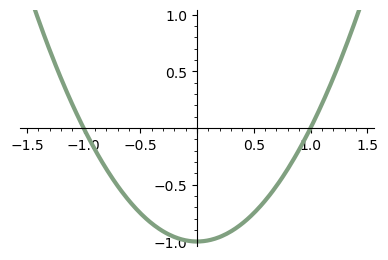

In [1]:
f(x)=x^2-1
show(f)
show(f(2))
plot(f,(x,-1.5,1.5),ymin=-1,ymax=1,aspect_ratio=1,thickness=3,color='#80a080',figsize=(4,3))

Εάν θέλουμε μεταβλητή διαφορετική από `x` (και ανάλογα `y`, `z`) θα πρέπει αυτές να δηλωθούν ως συμβολικές. Ακολουθεί η συνάρτηση $ f(a, b) = a^2 + b^2 $

In [2]:
# Το SR. δεν είναι υποχρεωτικό
a = SR.var('a')
b = SR.var('b')
g(a, b) = a^2 + b^2
show(g)
g(2, 3) 
plot3d(g,(a,-1,1),(b,-1,1))

(a, b) |--> a^2 + b^2

Graphics3d Object

## Δίκλαδες συναρτήσεις

Η συνάρτηση `piecewise` μας επιτρέπει να ορίζουμε συναρτήσεις της μορφής:
$$
f(x) =
\begin{cases} 
\frac{\cos(x)}{x}, & \text{για } x \neq 0 \\
0, & \text{για } x = 0
\end{cases}
$$
Αρχικά δηλώνουμε τους κλάδους της και στη συνέχεια με την `piecewise` την ορίζουμε ως μία στα διαστήματα που επιθυμούμε.

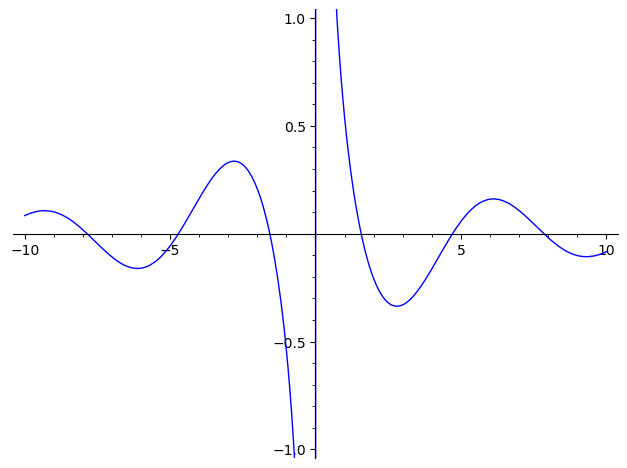

In [3]:
f1(x) = cos(x)/x
f2(x) = 0
f = piecewise ([[(0 ,0) ,f2 ] ,[( - infinity ,0) ,f1 ] ,[(0 , infinity ),f1 ]] )
plot(f,(x,-10,10),ymin=-1,ymax=1)

# Εύρεση ριζών

## solve

Με την `solve` μπορούμε να βρούμε τις ρίζες μίας εξίσωσης ή, αν θέσουμε την συνάρτηση μόνο και όχι εξίσωση, τα σημεία όπου αυτή μηδενίζει. Η `solve` επιστρέφει λίστα τιμών.

[x == 2]

[x == -1, x == 1]

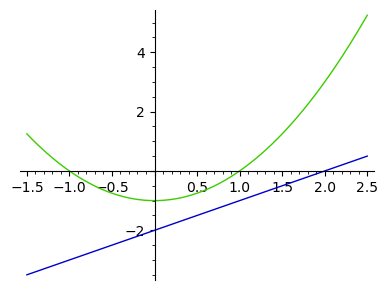

In [4]:
f(x) = x-2
show(solve(f==0,x))
g(x)=x^2-1
show(solve(g,x))
plot([f,g],(x,-1.5,2.5),figsize=(4,3))

Εκτυπώνοντας τις λύσεις παρατηρούμε ότι τα αποτελέσματα της `solve` επιστρέφονται ως εξισώσεις τύπου `x == value`. Για να εξαχθεί η αριθμητική τιμή από το αποτέλεσμα, μπορεί να χρησιμοποιηθεί η μέθοδος `rhs()` (right-hand side), που θα δώσει το δεξί μέρος της εξίσωσης, δηλαδή την τιμή. Επίσης, τα αποτελέσματα, ακόμη και αν είναι μόνο μία η λύση, επιστρέφονται ως λίστα. Θα πρέπει με `[]` να πάρουμε τη λύση που θέλουμε.

In [5]:
f(x) = x-2
s= solve(f==0,x)
s[0].rhs()

2

Στην εξίσωση
$$
x^2+1==0
$$
δεν υπάρχουν πραγματικές ρίζες. Η solve θα μας επιστρέψει και τις μιγαδικές εκτός αν ορίσουμε ότι επιθυμούμε οι λύσεις να είναι στο πεδίο των πραγματικών με την παράμετρο `domain` και την τιμή `PR`.
# TODO, δεν δουλεύει, να ψάξω

In [6]:
f(x)=x^2+1
show(solve(f,x))
show(solve(f,x,domain='RR'))

[x == -I, x == I]

[x == -I, x == I]

Η solve μπορεί να χρησιμοποιηθεί για να βρεθούν κοινά σημεία συναρτήσεων.

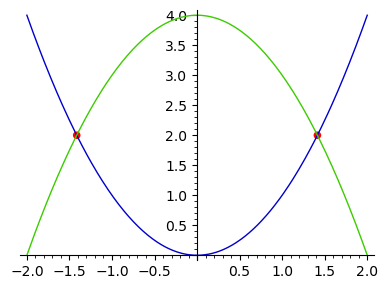

In [7]:
# Ορισμός συναρτήσεων
f = x^2
g = 4 - x^2
# Εύρεση κοινών σημείων
common = solve(f == g, x);
p = points([(common[0].rhs(),f(x=common[0].rhs())),(common[1].rhs(),f(x=common[1].rhs()))], color='red', size=30)
pl = plot([f,g],(x,-2,2),figsize=(4,3))
p + pl

## find_root

Το ίδιο και με την `find_root`. Η διαφορά τους είναι ότι η  `find_root` απαιτεί το διάστημα στο οποίο θα ψάξει για ρίζα και την βρίσκει προσεγγιστικά με μεθόδους αριθμητικής ανάλυσης. Η `solve` με την σειρά της επιλύει συμβολικά, αναλυτικά την εξίσωση.

In [8]:
h(x) = x - 2
find_root(h,0,4)

/ext/sage/10.4/local/var/lib/sage/venv-python3.12.4/lib/python3.12/site-packages/scikits/__init__.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  __import__("pkg_resources").declare_namespace(__name__)


/ext/sage/10.4/local/var/lib/sage/venv-python3.12.4/lib/python3.12/site-packages/scikits/__init__.py:1: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('scikits')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  __import__("pkg_resources").declare_namespace(__name__)


2.0

Η διαφορά τους φαίνεται και στο αποτέλεσμα που θα επιστραφεί αν ζητήσουμε τις ρίζες της εξίσωσης:
$$
x^2-2=0
$$

Πέρα από το αποτέλεσμα που στην περίπτωση της `find_root` δίνεται αριθμητικά προσεγγιστικά, παρατηρούμε ότι επιστρέφεται η πρώτη ρίζα που θα βρεθεί από την μέθοδο αριθμητικής ανάλυσης που χρησιμοποιείται (π.χ. μέθοδος της διχοτόμησης).

[x == -sqrt(2), x == sqrt(2)]

1.4142135623731364

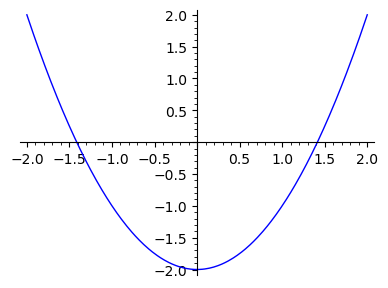

In [9]:
f(x) = x^2 - 2
show(solve(f==0, x))
show(find_root(f==0, -2,2))
plot(f,(x,-2,2),figsize=(4,3))

Για να βρούμε και άλλες ρίζες θα πρέπει να κάνουμε πιο συγκεκριμένο το διάστημα.

In [10]:
f(x) = x^2 - 2
show(find_root(f==0, -2,0))
show(find_root(f==0, 0,2))

-1.4142135623730951

1.4142135623731364

Υπάρχει ο κίνδυνος, στο διάστημα που θα ορίσουμε, να μην βρεθεί ρίζα. Τότε θα συμβεί εξαίρεση.

In [11]:
f(x) = x^2 - 2
show(find_root(f==0, 2,3))

RuntimeError: f appears to have no zero on the interval

# Όρια

Ο υπολογισμός ορίων μίας συνάρτησης γίνεται με την `limit`.

Στο επόμενο παράδειγμα υπολογίζεται το όριο:
$$
\lim_{x \to 0} \frac{\sin(x)}{x}
$$

In [12]:
limit(sin(x)/x, x=0)

1

## Άπειρο

Ακολουθεί όριο
$$
\lim_{x \to \infty} \frac{1}{x}
$$

In [13]:
 limit(1/x, x=infinity) # limit(1/x, x=oo)

0

---
**Παράδειγμα:**

Θα ζητήσουμε από το Sage να μας επιστρέψει το επόμενο όριο.
$$
\lim_{x \to \infty} \frac{\cos(x)}{x}
$$

Στη συνέχεια, και γνωρίζοντας ότι:

$$
-\frac{1}{|x|} \leq \frac{\cos(x)}{x} \leq \frac{1}{|x|} εφόσον -1 \leq \cos(x) \leq 1
$$
και
$$
\lim_{x \to \infty} \frac{1}{|x|}=0, \lim_{x \to \infty} -\frac{1}{|x|}=0
$$

κάτι που μπορούμε εύκολα και πάλι να επιβεβαιώσουμε πάλι με την limit, θα δημιουργήσουμε γραφική παράσταση και των τριών συναρτήσεων.

In [14]:
limit ( cos(x)/x, x= infinity ),limit ( -1/x, x= infinity ),limit ( 1/x, x= infinity )

(0, 0, 0)

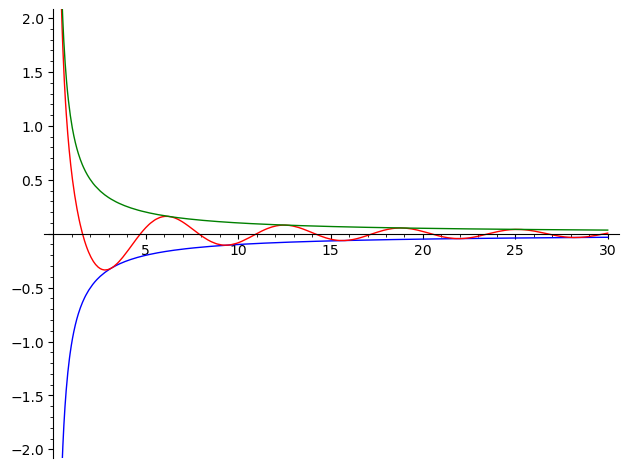

In [15]:
p1 = plot(-1/abs(x),(x,0,30),ymin=-2,ymax=2,color='blue')
p2 = plot(cos(x)/(x),(x,0,30),color='red')
p3 = plot(1/abs(x),(x,0,30),color='green')
p1+p2+p3

## Πλευρικά όρια

Μπορούν να υπολογιστούν τα αριστερά και δεξιά όρια με την παράμετρο `dir` και τιμές `-` και `+` αντίστοιχα. Έστω τα πλευρικά όρια στο x=0 για την
$$
\frac{x^2 - 1}{x - 1}
$$

In [16]:
limit((x^2 - 1)/(x - 1), x=1, dir='-'), limit((x^2 - 1)/(x - 1), x=1, dir='-')

(2, 2)

---
**Παράδειγμα:**


Για να εξετάσουμε την συνάρτηση 
$$
f(x) = \frac{1}{x - 1},
$$
υπολογίζουμε τα πλευρικά όρια καθώς $x$ πλησιάζει το $1$.

- **Αριστερό Όριο**:
  $$
  \lim_{{x \to 1^-}} \frac{1}{x - 1} = -\infty
  $$

- **Δεξί Όριο**:
  $$
  \lim_{{x \to 1^+}} \frac{1}{x - 1} = +\infty
  $$

Αυτό σημαίνει ότι καθώς πλησιάζουμε το  x = 1:

- Από την αριστερή πλευρά, η τιμή της συνάρτησης κατεβαίνει στο αρνητικό άπειρο.

- Από τη δεξιά πλευρά, η τιμή της ανεβαίνει στο θετικό άπειρο.

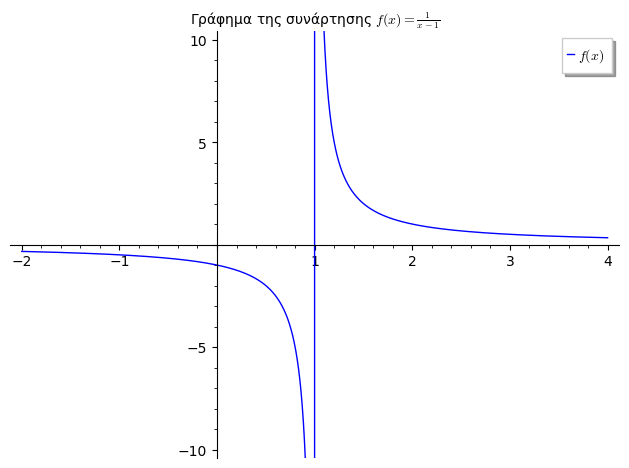

In [17]:
f(x)=1/(x-1)
plot(f, (x, -2, 4), title='Γράφημα της συνάρτησης $f(x) = \\frac{1}{x - 1}$', color='blue', ymin=-10, ymax=10, legend_label='$f(x)$')

In [18]:
# Δημιουργία της συνάρτησης
x = var('x')
f = 1 / (x - 1)

# Υπολογισμός πλευρικών ορίων στο x=1
leftLimit = limit(f, x=1, dir='-')
rightLimit = limit(f, x=1, dir='+')

# Εκτύπωση πλευρικών ορίων
leftLimit, rightLimit

(-Infinity, +Infinity)

# Διαφορικός Λογισμός

## Παράγωγος

Θα πρέπει η συνάρτηση της οποίας θα υπολογίσουμε την παράγωγο να είναι συμβολική. Υπενθυμίζεται ότι το `x` αποτελεί εξορισμού συμβολική μεταβλητή. Η συνάρτηση που υπολογίζει παραγοντικά είναι η `diff`. Στο παράδειγμα που ακολουθεί υπολογίζεται η παράγωγος της:
$$ 
f(x) = x^4 + 3x^3 + 2x^2 
$$

Υπενθυμίζεται ότι η `show` κάνει την εμφάνιση περισσότερο ευπαρουσίαστη.

4*x^3 + 9*x^2 + 4*x

17

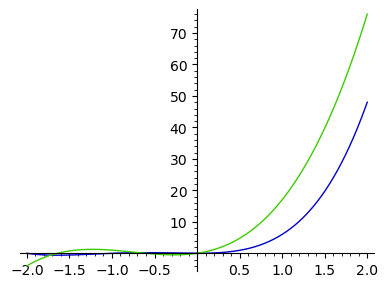

In [19]:
f = x^4 + 3*x^3 + 2*x^2
fprime = diff(f, x)
show(fprime)
show(diff(f, x)(x=1))
plot([f,fprime],(x,-2,2),figsize=(4,3))

Μπορούμε να χρησιμοποιήσουμε τον γνωστό τύπο
$$
y - f(x_0)=f'(x_0)(x-x_0)
$$
ώστε να βρούμε (και να σχεδιάσουμε) και την εφαπτομένη της συνάρτησης στο a = 1

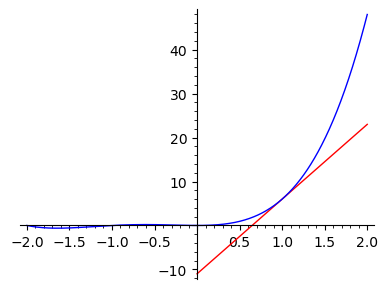

In [20]:
a=1
fp = plot(f,(x,-2,2),figsize=(4,3))
gp = plot(fprime(x=a)*(x-a)+f(x=a),(x,0,2),color="red")
gp+fp

Εναλλακτικά, παίρνουμε την 1η παράγωγο μέσω της μεθόδου `derivative()`.

In [21]:
show(f.derivative())

4*x^3 + 9*x^2 + 4*x

## Παράγωγοι n-ης τάξης

Θέτοντας μία τρίτη παράμετρο, πέρα από την συνάρτηση και τη μεταβλητή ως προς την οποία παραγωγίζουμε, υπολογίζουμε 2η 3η κ.ο.κ. παράγωγο.

In [22]:
show(diff(f, x,2))
show(diff(f, x,3))

12*x^2 + 18*x + 4

24*x + 18

## Μερικές παράγωγοι

Όταν έχουμε μια συνάρτηση πολλών μεταβλητών έχουμε την δυνατότητα εύρεση της παραγώγου της σε σχέση με μία από αυτές τις μεταβλητές, κρατώντας τις υπόλοιπες σταθερές.

Θα υπολογίσουμε τις μερικές παραγώγους της συνάρτησης που ακολουθεί σε σχέση με το x και το y.
$$ 
f(x, y) = x^2 + y^2 + 3xy
$$

In [23]:
var('y')
f(x, y) = x^2 + y^2 + 3*x*y
dfdx = diff(f, x)
dfdy = diff(f, y)
df2dxdy = diff(f, x, y)
dfdx,dfdy,df2dxdy

((x, y) |--> 2*x + 3*y, (x, y) |--> 3*x + 2*y, (x, y) |--> 3)

Μερικές παράγωγοι 2ης ή ανώτερης τάξης μπορούν να υπολογιστούν με την ίδια λογική με τις παραγώγους ανώτερης τάξης.

In [24]:
var('y')
f(x, y) = x^2*y + x*sin(y^2)
d2fdx2 = diff(f, x,2)
d2fdx2

(x, y) |--> 2*y

Αν σε μία συνάρτηση πολλών μεταβλητών καλέσουμε την `gradient` της συνάρτησης με τις μεταβλητές ως προς τις οποίες θα παραγωγίσουμε, υπολογίζουμε την
$$
\nabla f
$$

In [25]:
var('x y')
f =x^2 + y^2 + 3*x*y
f.gradient([x, y])

(2*x + 3*y, 3*x + 2*y)

## Ακρότατα συνάρτησης

Ως γνωστών για να παρουσιάζει μία συνάρτηση f ακρότατο σε ένα σημείο θα πρέπει
$$
f'(x_{0})=0
$$
Θα μελετήσουμε την συνάρτηση
$$
f(x) = \frac{1}{2x^2 + 1}
$$

Αρχικά αφού δηλώσουμε την συνάρτηση θα μελετήσουμε την γραφική παράστασή της.

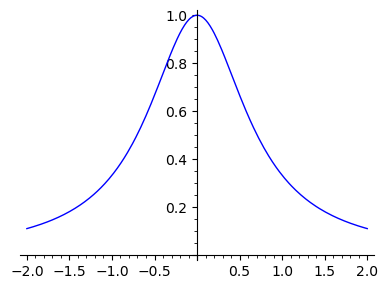

In [26]:
f(x) = 1/(2* x ^2+1)
plot (f(x), (x ,-2,2), ymin =0, ymax =1,figsize =(4,3))

Στην συνέχεια θα βρούμε την παράγωγό της και τα σημεία στα οποία αυτή μηδενίζεται. Για να το καταφέρουμε θα χρησιμοποιήσουμε τη `solve`.

In [27]:
df = diff(f,x)
show(df)
s = solve(df==0,x)
print('(',s[0].rhs(),',',f(x=s[0].rhs()),')', sep='')

x |--> -4*x/(2*x^2 + 1)^2

(0,1)


Στο σημείο (0,1), όπως φάνηκε και από την γραφική παράσταση, η συνάρτηση έχει ακρότατο. Μπορούμε να πάρουμε την 2η παράγωγό της και βλέποντας ότι είναι αρνητική, συμπεραίνουμε ότι στο (0,1) έχουμε τοπικό μέγιστο.

In [28]:
diff (f(x),x ,2)(x=0)

-4

## TODO μελέτη προσήμου

In [29]:

#df(x).sign_chart(x, plot=True)

# Ολοκληρωτικός Λογισμός

## Αόριστο ολοκλήρωμα

Για να υπολογίσουμε το αόριστο ολοκλήρωμα μίας συνάρτησης κάνουμε χρήση της συνάρτησης `integral` με παραμέτρους την συνάρτηση και την μεταβλητή ως προς την οποία το υπολογίζουμε.

In [30]:
f = x^2 + 3*x + 2
show(integral(f, x))
show(integral(cos(x),x))

1/3*x^3 + 3/2*x^2 + 2*x

sin(x)

## Ορισμένο ολοκλήρωμα

Για ορισμένο ολοκλήρωμα θα πρέπει να θέσουμε και το διάστημα [α,β] στο οποίο αυτό θα υπολογιστεί.

In [31]:
f(x) = cos(x)
show(integral(f,(x,0,pi/2)))

1

Θα υπολογίσουμε το ολοκλήρωμα της συνάρτησης:
$$
\int_{-1}^{1} \sin(2x^2) \, dx
$$
Επίσης, θα δημιουργήσουμε γραφική παράσταση με σκιασμένο το χωρίο του οποίου υπολογίζουμε το εμβαδόν.

In [32]:
f(x) = sin(2*x^2)
integral(f(x), x, -1, 1),N(integral(f(x), x, -1, 1))

(1/4*sqrt(pi)*((I + 1)*erf(sqrt(2*I)) - (I - 1)*erf(sqrt(-2*I))),
 0.997623711325421)

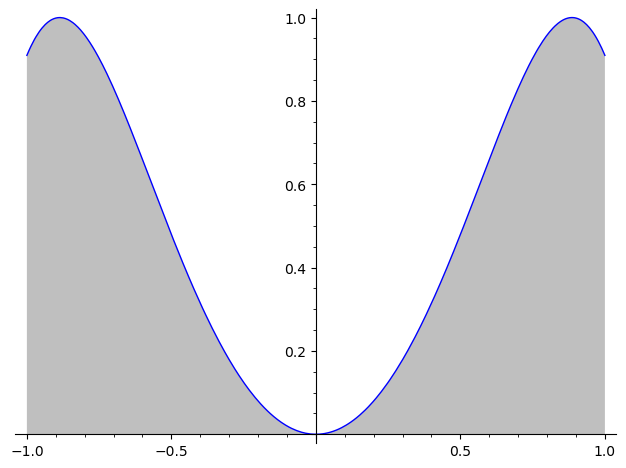

In [33]:
plot(f(x), (x, -1, 1), fill=0, fillcolor='gray')

---
**Παράδειγμα**

Υπολογίστε το εμβαδόν ανάμεσα στον άξονα x και την συνάρτηση sin(x) από π έως 2π.

Υπολογίστε το επόμενο ολοκλήρωμα
$$
\int_{\pi}^{2\pi} \sin(x) \, dx
$$

Σχεδιάστε γραφική παράσταση με σκιασμένα τα μέρη που μας ενδιαφέρουν.

In [34]:
f(x) = sin(x)
g(x) = abs(f(x))
integral(g, x, pi, 2*pi)

2

In [35]:
f(x) = sin(x)
integral(f(x), x, -pi, 2*pi)

-2

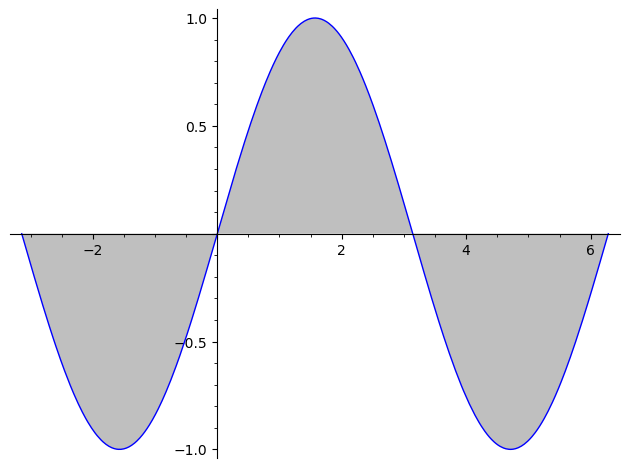

In [36]:
plot(f(x), (x, -pi, 2*pi), fill=0, fillcolor='gray')

## Διπλό Ολοκλήρωμα

$$
f(x, y) = x^2 + y^2
$$

$$
\int_0^1 \int_0^1 (x^2 + y^2) \, dx \, dy
$$

In [37]:
var('x y')
f(x, y) = x^2 + y^2
plot3d(f,(x,-1,1), (y,-1,1))+plot3d(0,(x,-1,1), (y,-1,1),color='red')

Graphics3d Object

In [38]:
integral_result = integral(integral(f(x, y), x, 0, 1), y, 0, 1)
integral_result

2/3